In [1]:
import io
import random
import zipfile
from dataclasses import dataclass
from typing import List, Dict, Tuple

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, f1_score

In [2]:
SMS_SPAM_UCI_ZIP = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
MIT_WORDLIST_10000 = "https://www.mit.edu/~ecprice/wordlist.10000"

In [3]:
@dataclass(frozen=True)
class ExperimentConfig:
    # Data split
    test_size: float = 0.30
    random_state: int = 42

    # Attack
    good_words_per_email: int = 50     # K
    attack_steps: int = 20             # number of N points on the curve
    max_attack_emails: int | None = None  # if None, attack all spam in test
    attack_selection_seed: int = 123   # controls which spam messages get attacked

In [4]:
def download_sms_spam_collection(url: str = SMS_SPAM_UCI_ZIP) -> pd.DataFrame:

    resp = requests.get(url, timeout=60)
    resp.raise_for_status()

    with zipfile.ZipFile(io.BytesIO(resp.content)) as zf:
        with zf.open("SMSSpamCollection") as f:
            raw = f.read().decode("utf-8", errors="replace")

    rows = []
    for line in raw.splitlines():
        label_text = line.split("\t", 1)
        if len(label_text) != 2:
            continue
        label, text = label_text[0].strip(), label_text[1].strip()
        if label in {"ham", "spam"} and text:
            rows.append((label, text))

    return pd.DataFrame(rows, columns=["label", "text"])


def download_wordlist(url: str = MIT_WORDLIST_10000) -> List[str]:

    resp = requests.get(url, timeout=60)
    resp.raise_for_status()
    return [w.strip().lower() for w in resp.text.splitlines() if w.strip()]


In [5]:
df = download_sms_spam_collection()
dictionary_words = download_wordlist()

df.head(), df["label"].value_counts()

(  label                                               text
 0   ham  Go until jurong point, crazy.. Available only ...
 1   ham                      Ok lar... Joking wif u oni...
 2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
 3   ham  U dun say so early hor... U c already then say...
 4   ham  Nah I don't think he goes to usf, he lives aro...,
 label
 ham     4827
 spam     747
 Name: count, dtype: int64)

In [6]:
def make_nb_pipeline(alpha: float = 1.0) -> Pipeline:

    return Pipeline(
        steps=[
            ("vect", CountVectorizer(lowercase=True)),
            ("nb", MultinomialNB(alpha=alpha)),
        ]
    )

In [7]:
def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro")),
    }

In [8]:
def get_nb_feature_names(vect: CountVectorizer) -> np.ndarray:
    """
    Robust way to get feature names from CountVectorizer.
    """
    return vect.get_feature_names_out()


def rank_ham_indicative_words(model: Pipeline, top_n: int = 5000) -> List[str]:
    """
    Return words sorted by ham-vs-spam log-odds (descending).
    """
    vect: CountVectorizer = model.named_steps["vect"]
    nb: MultinomialNB = model.named_steps["nb"]

    classes = list(nb.classes_)
    if "ham" not in classes or "spam" not in classes:
        raise ValueError(f"Unexpected classes: {classes}")

    ham_idx = classes.index("ham")
    spam_idx = classes.index("spam")

    # log P(word|class)
    logp = nb.feature_log_prob_
    score = logp[ham_idx] - logp[spam_idx]  # higher => more ham-indicative

    feature_names = get_nb_feature_names(vect)
    top_idx = np.argsort(score)[::-1][:top_n]
    return feature_names[top_idx].tolist()


def build_good_word_list(model: Pipeline, dictionary_words: List[str], top_n: int = 5000) -> List[str]:
    """
    Intersect ham-indicative words with external dictionary.
    """
    dict_set = set(dictionary_words)
    candidates = rank_ham_indicative_words(model, top_n=top_n)
    return [w for w in candidates if w in dict_set]

In [9]:
def append_good_words(text: str, good_words: List[str], k: int) -> str:
    if k <= 0:
        return text
    suffix = " ".join(good_words[:k])
    return f"{text} {suffix}".strip()

In [10]:
cfg = ExperimentConfig()

X = df["text"].to_numpy()
y = df["label"].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=cfg.test_size,
    random_state=cfg.random_state,
    stratify=y
)

model = make_nb_pipeline(alpha=1.0)
model.fit(X_train, y_train)

y_pred_clean = model.predict(X_test)
baseline = compute_metrics(y_test, y_pred_clean)

baseline

{'accuracy': 0.9838613269575612, 'macro_f1': 0.9643279356542958}

In [11]:
def select_spam_indices_to_attack(y_test: np.ndarray, seed: int, max_attack: int | None) -> List[int]:
    """
    Returns a shuffled list of spam indices in the test set, truncated to max_attack if provided.
    """
    spam_indices = np.where(y_test == "spam")[0].tolist()
    rng = random.Random(seed)
    rng.shuffle(spam_indices)

    if max_attack is None:
        return spam_indices
    return spam_indices[: min(max_attack, len(spam_indices))]


spam_attack_order = select_spam_indices_to_attack(
    y_test=y_test,
    seed=cfg.attack_selection_seed,
    max_attack=cfg.max_attack_emails
)

len(spam_attack_order), spam_attack_order[:10]

(224, [1448, 845, 1246, 1074, 1242, 594, 1255, 628, 108, 1343])

In [12]:
good_words = build_good_word_list(model, dictionary_words, top_n=5000)

len(good_words), good_words[:30]

(2490,
 ['gt',
  'lt',
  'he',
  'da',
  'she',
  'later',
  'amp',
  'anything',
  'ask',
  'home',
  'my',
  'doing',
  'said',
  'cos',
  'come',
  'very',
  'but',
  'lol',
  'morning',
  'nice',
  'sure',
  'went',
  'something',
  'll',
  'ok',
  'did',
  'gonna',
  'around',
  'his',
  'sleep'])

In [13]:
def make_attack_points(max_attack: int, steps: int) -> List[int]:
    """
    Returns a sorted list of unique N values including 0 and values spaced up to max_attack.
    """
    if max_attack <= 0:
        return [0]
    pts = [0] + [int(round(x)) for x in np.linspace(1, max_attack, steps)]
    return sorted(set(pts))


def evaluate_under_attack(
    model: Pipeline,
    X_test: np.ndarray,
    y_test: np.ndarray,
    spam_attack_order: List[int],
    good_words: List[str],
    k: int,
    steps: int
) -> pd.DataFrame:
    """
    For each N, attack the first N spam messages in spam_attack_order and evaluate.
    """
    max_attack = len(spam_attack_order)
    points = make_attack_points(max_attack=max_attack, steps=steps)

    records = []
    for n_attack in points:
        X_mod = X_test.copy()

        for idx in spam_attack_order[:n_attack]:
            X_mod[idx] = append_good_words(X_mod[idx], good_words, k)

        y_pred = model.predict(X_mod)
        m = compute_metrics(y_test, y_pred)

        records.append({
            "attacked_emails": n_attack,
            "good_words_per_email": k,
            **m
        })

    return pd.DataFrame(records)


if len(good_words) < cfg.good_words_per_email:
    raise RuntimeError(
        f"Not enough good words ({len(good_words)}) to append "
        f"{cfg.good_words_per_email}. Reduce cfg.good_words_per_email."
    )

results = evaluate_under_attack(
    model=model,
    X_test=X_test,
    y_test=y_test,
    spam_attack_order=spam_attack_order,
    good_words=good_words,
    k=cfg.good_words_per_email,
    steps=cfg.attack_steps
)

results.head(), results.tail()

(   attacked_emails  good_words_per_email  accuracy  macro_f1
 0                0                    50  0.983861  0.964328
 1                1                    50  0.983264  0.962934
 2               13                    50  0.977286  0.948686
 3               24                    50  0.970711  0.932325
 4               36                    50  0.964734  0.916775,
     attacked_emails  good_words_per_email  accuracy  macro_f1
 16              177                    50  0.888822  0.632750
 17              189                    50  0.881650  0.592878
 18              201                    50  0.875075  0.553171
 19              212                    50  0.868500  0.510016
 20              224                    50  0.861925  0.462921)

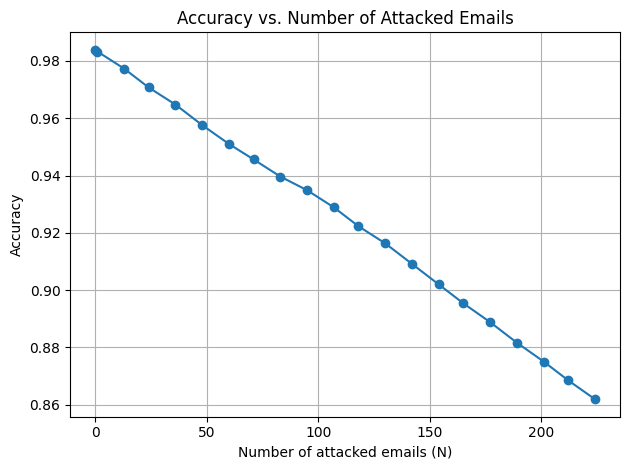

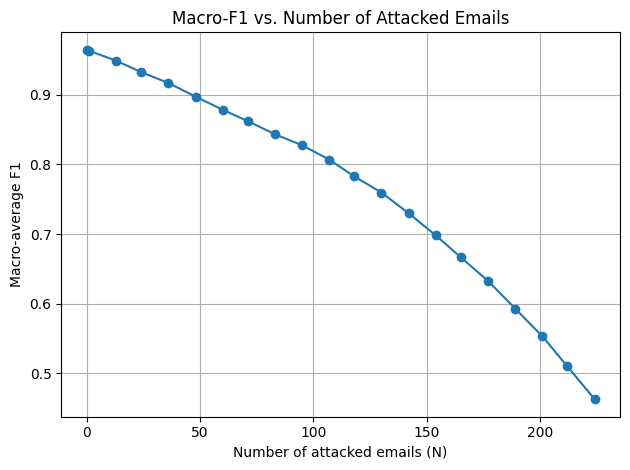

In [14]:
def plot_curve(x: pd.Series, y: pd.Series, xlabel: str, ylabel: str, title: str) -> None:
    plt.figure()
    plt.plot(x, y, marker="o")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


plot_curve(
    results["attacked_emails"],
    results["accuracy"],
    xlabel="Number of attacked emails (N)",
    ylabel="Accuracy",
    title="Accuracy vs. Number of Attacked Emails"
)

plot_curve(
    results["attacked_emails"],
    results["macro_f1"],
    xlabel="Number of attacked emails (N)",
    ylabel="Macro-average F1",
    title="Macro-F1 vs. Number of Attacked Emails"
)

Saved: attack_results.csv, attack_curve_accuracy.png, attack_curve_macro_f1.png
Baseline: {'accuracy': 0.9838613269575612, 'macro_f1': 0.9643279356542958}


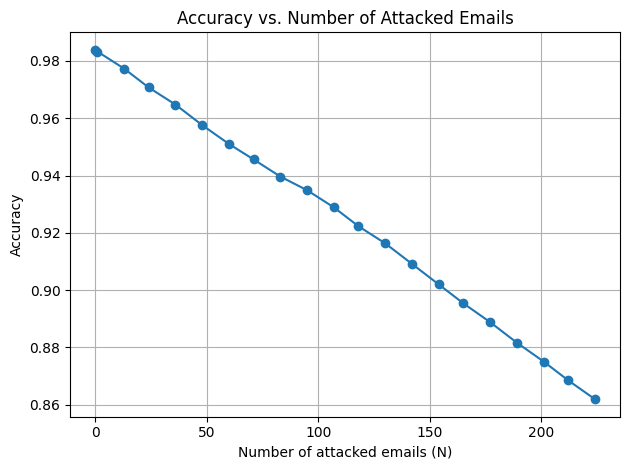

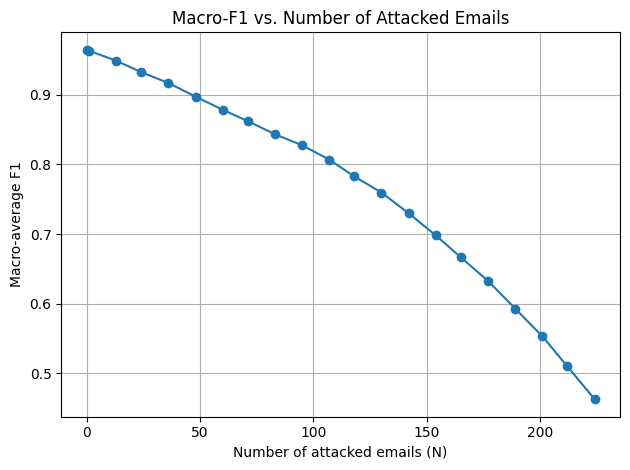

In [15]:
results.to_csv("attack_results.csv", index=False)

# Save figures as PNG as well (optional)
plt.figure()
plt.plot(results["attacked_emails"], results["accuracy"], marker="o")
plt.xlabel("Number of attacked emails (N)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs. Number of Attacked Emails")
plt.grid(True)
plt.tight_layout()
plt.savefig("attack_curve_accuracy.png", dpi=200)

plt.figure()
plt.plot(results["attacked_emails"], results["macro_f1"], marker="o")
plt.xlabel("Number of attacked emails (N)")
plt.ylabel("Macro-average F1")
plt.title("Macro-F1 vs. Number of Attacked Emails")
plt.grid(True)
plt.tight_layout()
plt.savefig("attack_curve_macro_f1.png", dpi=200)

print("Saved: attack_results.csv, attack_curve_accuracy.png, attack_curve_macro_f1.png")
print("Baseline:", baseline)

In [16]:
# Show a few spam examples before/after attack and predictions
example_indices = spam_attack_order[:5]

for idx in example_indices:
    original = X_test[idx]
    attacked = append_good_words(original, good_words, cfg.good_words_per_email)

    pred_orig = model.predict([original])[0]
    pred_attk = model.predict([attacked])[0]

    print("=" * 80)
    print("ORIGINAL PRED:", pred_orig)
    print(original[:200], "..." if len(original) > 200 else "")
    print("-" * 80)
    print("ATTACKED  PRED:", pred_attk)
    print(attacked[:200], "..." if len(attacked) > 200 else "")

ORIGINAL PRED: spam
URGENT! We are trying to contact U. Todays draw shows that you have won a £800 prize GUARANTEED. Call 09050003091 from land line. Claim C52. Valid 12hrs only 
--------------------------------------------------------------------------------
ATTACKED  PRED: ham
URGENT! We are trying to contact U. Todays draw shows that you have won a £800 prize GUARANTEED. Call 09050003091 from land line. Claim C52. Valid 12hrs only gt lt he da she later amp anything ask hom ...
ORIGINAL PRED: spam
Do you want a NEW video phone750 anytime any network mins 150 text for only five pounds per week call 08000776320 now or reply for delivery tomorrow 
--------------------------------------------------------------------------------
ATTACKED  PRED: ham
Do you want a NEW video phone750 anytime any network mins 150 text for only five pounds per week call 08000776320 now or reply for delivery tomorrow gt lt he da she later amp anything ask home my doin ...
ORIGINAL PRED: spam
URGENT. Important i